Program 1

Find and indicate the 4 strongest corners in image photo_1.jpg using Haris Corner Detection.
Find and indicate key points on the same image using the SIFT method.

Grading
2 points each for the following:
- Haris corner detection.
- SIFT.
4 points total.

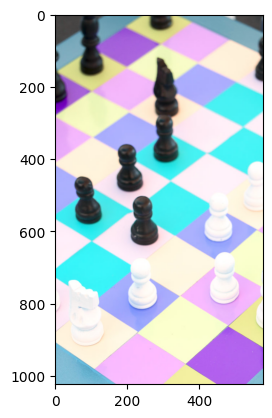

In [2]:
import cv2 as cv
import sys
from matplotlib import pyplot as plt
import numpy as np

def get_original_image(name):
    image = cv.imread(cv.samples.findFile(f"resources/{name}.jpg"))

    if image is None:
        sys.exit("Could not read the image.")

    return image

original_img = get_original_image("photo_1")

plt.imshow(original_img)

Haris Corner Detection

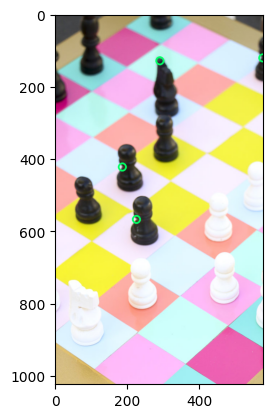

In [136]:
# load original image
img = get_original_image("photo_1")

# convert to gray scale
gray_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# convert to floating point format
gray = np.float32(gray_img)

# run harris detection
block_size = 20 # check neighborhoods of blockSize x blockSize around each pixel
kernel_size = 7 # dimensions of kernel for estimating derivatives of image
k_filter = 0.1 # filter
dst = cv.cornerHarris(gray, blockSize=block_size, ksize=kernel_size, k=k_filter)

# dilate
dst_dilated = cv.dilate(dst, np.ones((5,5),np.int8))

# keep only local maximum corners and the ones that pass the threshold
threshold = 0.1 * dst.max()
largest_in_neighbourhood = dst == dst_dilated
over_threshold = dst > threshold
corner_mask = largest_in_neighbourhood & over_threshold

# print(corner_mask)

# obtain corner coordinates
y_cords, x_cords = np.where(corner_mask)

# print([(int(x),int(y)) for x, y in zip(ys, xs)])

# sort corners according to harris evalution
corner_scores = dst[y_cords, x_cords]
top_indices = np.argsort(corner_scores)[-4:]

# print(corner_scores)
# print(np.argsort(corner_scores))
# print(corner_scores[np.argsort(corner_scores)])

top_corners = list(zip(x_cords[top_indices], y_cords[top_indices]))

# mark top 4 corners
for x, y in top_corners:
    cv.circle(img, (x, y), radius=10, color=(100, 255, 0), thickness=3)

img_with_harris_corners = img
plt.imshow(cv.cvtColor(img_with_harris_corners, cv.COLOR_BGR2RGB))